# Hierarchical Clustering
## First Question: Why?
Have you ever heard the old idea of "Divide and Conquer"? The general idea is as follows: If you are faced with a large problem that is beyond your ability to solve or handle, try breaking it down into a series of smaller problems which are easier to handle. Today, we will be tackling clustering with that approach, as well as its exact opposite: Building from the ground up.

When we learned about K-Means and DBSCAN, one thing stood out:
- For K-Means, you need to know enough about the data or its underlying structure to estimate how many clusters you need.
- For DBSCAN, you need to know enough about your data's positioning to estimate a good number of points needed to form a "core" and how far away they are.

In general, you could imagine many cases where this is not true! What if you don't know how many clusters should be formed? What if you don't have time to plot and test your data to estimate closeness and density?

This isn't to mention the key problems with each algorithm: K-Means is spherical and DBSCAN needs constant density.

So, what if we could avoid that? What if we had an algorithm that takes exactly 0 parameters (not including the distance metric), and also helps inform you on how many groups there naturally should be? Such an algorithm would be nearly perfect, right?

**Presenting: Hierarchical Clustering!**

## The Basics of Hierarchical Clustering
Hierarchical clustering, as suggested above, takes the approach of either "Divide and Conquer" or "Build From The Ground Up" for clustering. Unlike other algorithms, hierarchical clustering seeks to do one of two things:
- **Agglomerative:** Assume that all the points are their own cluster: Now combine the two closest "clusters". Repeat until all of the data is one big cluster.
- **Divisive:** Assume that all the points form one big cluster: Now split them along the line (in 2D) or plane (3D) or hyperplane (ND) that produces the two furthest apart resulting clusters.

One of these is naturally easier, but both have their advantages. If you want to identify big clusters, Divisive will find them faster, but finding those "split lines" is naturally a lot harder than finding two nearby clusters!

The beauty of this is that, at every step $i$, you have $i$ or $N-i$ clusters exactly! So, if at some point, you learn that you should have 10 clusters, simply run your algorithm until you are at step 10 or step $N-10$, depending on your choice of algorithm. This produces what we call a "Dendrogram", or a timeline of how the clusters are formed.

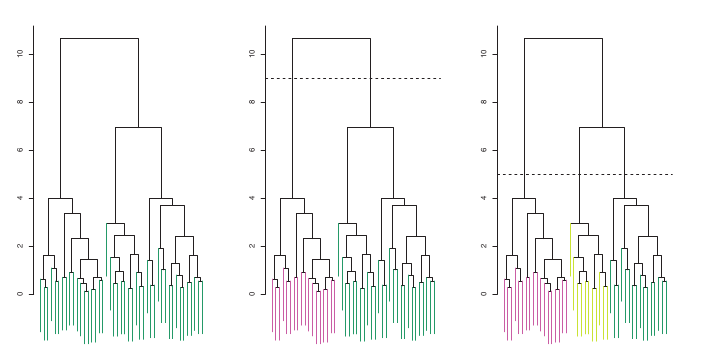

Figure 3.1: An example Dendrogram for arbitrary data. Taken from [1].


On the left of this image, you can see the entire history of when each item (a green line) was put into a cluster. If we decided that we only want 2 clusters, we can use the middle image, to split the lines into pink and green. Similarly, on the right image, we have 3 clusters: pink, yellow, and green.

This makes Hierarchical Clustering a perfect example of a "know-nothing" algorithm, an algorithm where you simply put the data in and see what clusters naturally form. With this in mind, let's take a look at the algorithm.

## The Algorithm
Since we have two different methods for building our clustering, today we will have to present you with TWO algorithms! Unlike last week, these algorithms are very very simple, so we can present them very easily.

```Python
def Agglomerative(Data):
    ClusterHistory = []

    Start with each data point as its own cluster

    while more than one cluster remains:
        Compute the distance between every pair of clusters
        Find the two closest clusters
        Merge those two clusters
        Record the merge in ClusterHistory

    Return ClusterHistory

def Divisive(Data):
	ClusterHistory = []

	Assign each data point to one big cluster
	Assign this cluster its "mean" location

	For i from 0 to N:
		Find the best split point across all your clusters
		Split that cluster into two
		Update the "mean" location of each cluster
		Add the list of clusters to ClusterHistory
```

And that's it! Of course, finding the best "split point" is extremely hard, so, in general, we often will choose to find the two closest clusters.

In many ways, this is the same approach to distance as K-Means. In that algorithm, for each point, we assigned it to the cluster with the nearest mean. This time, for each cluster, we combine the two with the nearest means!

So, if hierarchical is so simple *and* so useful... why don't we always use it?

## Pros and Cons
As must be clear by now, Hierarchical clustering is incredibly powerful. It builds a nested sequence of clusters with K ranging from 1 to N. It has many other pros too!

### Pros  
  
1. **No need to choose \(k\) at the start.**  
Unlike K-Means, hierarchical clustering builds a full dendrogram first.  
  
2. **It gives a visual history.**  
The dendrogram shows which points and clusters merged, and when.  
  
3. **It is useful for exploration.**  
If we do not know the structure of the data, hierarchical clustering can help us inspect possible groupings.  
  
4. **It is conceptually simple.**  
Start with small clusters, repeatedly merge the closest ones.  
  
### Cons  
  
1. **It is greedy.**  
Once two clusters are merged, they cannot be separated later. A bad early merge can affect the rest of the dendrogram.  This means it makes the best decision it can *from each step*. If there is a natural set of 3 splits that is obvious to a viewer, but when you look at the whole data, there *could* be a different split that cuts the data in half, which is worse overall, but better in-the-moment, Hierarchical will almost *always* choose that split.
  
2. **It can be slow for large datasets.**  
Hierarchical Clustering, like our other methods, needs to compare every single point to build an agglomerative method. For divisive, you need to solve the graph splitting problem, which is NP-Hard (i.e. Unsolvable). Therefore, the worse-case runtime is $\mathcal{O}(n^3)$ without special cases or taking advantage of heuristics.
  
3. **It still has choices.**  
We need to choose a distance metric and eventually where to cut the dendrogram, so you still have some choice to make, even if it is *nearly* the same choices you make for other methods.

## When To Use Hierarchical Clustering
So, our final question then: Since this method can be very time consuming, when should we use it? Well, there are a few key points:
1. You don't know how many clusters you want -> Use DBSCAN or Hierarchical
2. You care about how each possible number of clusters in the data (or want to compare many different numbers) -> Use Hierarchical
3. You know very little about the structure of your data -> Use Hierarchical

# Data Pre-Processing
Now, let's talk briefly about Data Pre-Processing. We have hinted for a few weeks that you need to pick the most appropriate type of "distance" with your data, and that more than just the simple euclidean distance exists. What we haven't done is explain **when** or **why** you would pick each one. There is also the question of normalising your data, and ensuring that it even can be clustered in the first place. So, let's get to answering it!

## Picking a Distance Metric
Here, we will talk about different ways of measuring distance. Each one corresponds to a different assumption of your data. For example, "do you want to use the straight line from A to B" or "do you only care about absolute distances" or "do you care about the angle between two points"? All of these are valid assumptions.

### Euclidean Distance
This is the one we have been using up until this point, and it is definitely the simplest. It assumes that you can easily draw a diagonal straight line between any two points to measure their distance. You can measure distance as follows:
$$d(\boldsymbol{x}, \boldsymbol{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$
### Manhattan Distance
Let's say that you can measure the distance in *each* dimension, but you can't mix them  (meaning you must count your steps in each dimension), so you aren't allowed to find a straight line between your points. This would be known as the "absolute" or "Manhattan" distance.

This is actually based on walking downtown in the city of Manhattan, where you need to follow the grids of streets, and you can't take any diagonal paths!
$$d(\boldsymbol{x}, \boldsymbol{y}) = \sum_{i=1}^n |x_i - y_i|$$
### Cosine Distance

Cosine distance measures the angle between two vectors. It asks whether two data points point in the same direction, rather than asking whether they have the same size. This is useful when we care about patterns or proportions more than total magnitude.

More intuitively, imagine you have two people applying for a job, and you're attempting to understand their background based on how often they put a word in their application, and your data looks like this:
- Person A:
	- Math: 10 times
	- Physics: 5 times
	- Art: 0 times
- Person B:
	- Math: 20 times
	- Physics: 10 times
	- Art: 0 times

You could do one of two things:
1. Standardise the data, but this may be hard to pick a single "scale" without checking the prevalence of every single word you care about, or
2. Use the cosine distance, which compares the pattern of word usage, even if one document is much longer than another.

In this case, you would likely guess that both Person A and B are math students with some physics background! It's formula is:
$$d(\boldsymbol{x}, \boldsymbol{y}) = 1 - \frac{\boldsymbol{x}\cdot\boldsymbol{y}}{\|\boldsymbol{x}\| \|\boldsymbol{y}\|}$$
### Mahalanobis Distance
This method accounts for correlations between data, and is honestly the most difficult of this set. Let's say you are measuring heights and weights: Well a taller person is almost guaranteed to be heavier! So, you need some way of asking "based on what we know of the underlying data, how *surprising* is this result?"

Of course, you need to know (or estimate) the covariance between parameters first, and we will explore it more later to cover that, but the formula is:
$$d(\boldsymbol{x}, \boldsymbol{y}) = \sqrt{(\boldsymbol{x} - \boldsymbol{y})^T S^{-1} (\boldsymbol{x} - \boldsymbol{y})}$$

Where $S$ is the covariance matrix for your data.
### When to (and not to) Use Each?
- Euclidean:
	- Good for physical and numerical data, or data where you can easily draw lines between things.
	- Bad for unscaled data, or data that has correlated features or is a "grid".
- Manhattan:
	- Good for counts and sparse data.
	- Bad for: Physical data.
- Cosine:
	- Good for feature counts or when intensity varies wildly, but you are about relative proportions.
	- Bad for when magnitude matters.
- Mahalanobis:
	- Good for correlated features.
	- Bad for small datasets, or when you don't know the covariance.

## Scaling
Earlier in this program, we discussed that your data must be scaled. Part of the reason for this can be seen in the following features:
1. Age - Ranges from 0 to 100 (generally).
2. Income - Ranges from 0 to 1,000,000 dollars.

If you just gave that data into your clustering algorithm, it would assume income is 10,000x more important than age . So, you generally need to ensure that your data is scaled. Here, we will present a few different scaling methods.

### Min-Max
This is the one we already covered: Scale all your features so that it ranges from 0 to 1. For each feature, $x_i$, just define the following:
$$x_{i, j, \mathrm{scaled}} = \frac{x_{i,j} - \min{x_i}}{\max{x_i} - \min{x_i}}$$
### Standardization
This method generally assumes that your data is normally distributed, or is almost normal, but it is very powerful, especially for later methods like Gaussian Mixture Modelling. For each feature, define $\mu_i = \mathrm{mean}(x_i)$ and $\sigma_i = \mathrm{standard deviation}(x_i)$. Then, for each datapoint $j$ of feature $i$, you get
$$z = \frac{x_{i,j} - \mu_i}{\sigma_i}$$

### Robust Scaling
Similar to above standard deviation, but using the median and interquartile range. Define $M = \mathrm{median}(x_i)$ and $S = \mathrm{Interquartile Range}(x_i)$ and do the same thing, this is called "Robust Scaling", and works very similarly to standard deviation for non-normal data.

$$x_{i, j, \mathrm{scaled}} = \frac{x_{i,j} - M_i}{IQR_i}$$

### Row Scaling
This is a final note, but sometimes you care about relations between the datapoints using patterns, not magnitude. Here, you would use the same scaling methods above, but applied to each **person** rather than each **feature**.

Put simply:
- Feature scaling asks: “Are the variables comparable?”  
- Row scaling asks: “Do we care about the pattern more than the total amount?”

## Missing and Different Data
One other thing we should handle is missing data and data that isn't simple to just cluster right away. In general, we have a few categories:
1. Missing Data:
	1. You tried to measure something like "height", but most people declined to answer.
	2. One person has holes in their data, such as forgetting to input age.
	3. Data with a clear pattern is missing a single point.
2. Duplicated Data: Where some measurement was duplicated.
3. Categorical Data: Where your measurements aren't numbers, but are yes/no, or red/blue/green, or other collections of words.

So, what do you do?
### Missing Feature
If you are missing a key feature for most of your data, like height above, in this case it is often best to remove that feature and see if you can continue your analysis.

### Missing Individual Data
If a single person or datapoint is missing a lot of its data, its often best to remove that person from the study. If they are critical, you will need to ask them the questions again.

### Filling in Missing Values
Here, you normal would simply remove the data, but there are other cases.

Sometimes we fill in missing values. This is called imputation. Simple choices include using the mean, median, or most common value. And sometimes you can perform what is called "interpolation". Based on the existing data, you can fit a "line of best fit" and choose the value that is missing using that line. Note that you **must** first check if this action is okay!

### Duplicated Data
If you noticed a single measurement was duplicated, you have 3 cases:
1. If you just have extra data -> Delete the extra
2. If the duplicated feature has a different *value* -> Likely delete the row or go redo the experiment. If valid, you could also average the data.
3. If you are missing another piece of data because of the duplicated feature -> See above!
### Categorical Data

Categorical data contains labels instead of numerical measurements.

If the category has only two options, such as yes/no, we can often use:

- no = 0
- yes = 1

If the category has more than two unordered options, do not encode it as 1, 2, 3, 4. That creates fake distances.

For example, if:

- red = 1
- blue = 2
- green = 3

then the algorithm thinks red is closer to blue than to green, even if the colors are just different categories.

Instead, use **one-hot encoding**, where each option becomes its own yes/no column. Though, you will then need to balance it such that these together are the same "weight" as one variable!

| Colour | is_red | is_blue | is_green |
|---|---:|---:|---:|
| red | 1 | 0 | 0 |
| blue | 0 | 1 | 0 |
| green | 0 | 0 | 1 |


## Feature Choice
Finally for data preprocessing: How do you choose which features are worth clustering over? If you give the algorithm many irrelevant variables, it may cluster over the things you don't care about. For example, for medical patients, you might have:
- Heart Rate
- Blood Pressure
- Age
- Postal Code
- ID Number

Out of these options, ID Number probably has no impact on their health.

Sometimes two features contain almost the same information. For example, temperature in Celsius and temperature in Fahrenheit are different columns, but they represent the same measurement. On Earth, the same is true for mass and weight.  Similarly, "package weight" and "shipping cost" are extremely similar.

If we include both, we may accidentally make temperature, or mass, or package weight count twice. So, if you are clustering something that uses both variables, consider using only one of them. We will discuss this more when we teach PCA.

So, before clustering, ask yourself:
1. What does each feature represent? Are any of them not relevant?
2. Do any features represent the same thing? If so, only use one.

# References
[1] James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning. In Springer Texts in Statistics. Springer US. https://doi.org/10.1007/978-1-0716-1418-1

Tasks

For this question list, we have 2 tasks for you:

    Preprocess some tree data
    Program Hierarchical Clustering and show its dendrogram


# Task - Build a Forest Family Tree

>Howdy Ranger,

>A group of hikers has discovered a never before seen tree species in Victoria Park. We've been calling it a "Truffalo Tree" for now, since it was found near a bunch of truffles. The Ontario Ministry of Natural Resources has asked you to help classify which tree family this new species belongs to, based on some ecological characteristics.

Here is some information about the new tree as well as other trees commonly found in the area:

|Species|Height (m)|Shade Tolerance (1-10)|Seed Size (mm)|Leaf Colour|Truffles Nearby|
|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|
|White Cedar|15|8|5|Green|0|
|Black Spruce|18|7|3|Green|0|
|Tamarack|20|4|4|Yellow|0|
|Red Maple|22|7|10|Red|0|
|Sugar Maple|25|9|12|Red|0|
|Truffalo Tree|40|3|7|Pink|1000|


# Preprocessing

The first thing we need to do is clean up the dataset given, there are a few issues to tackle:


*   "Truffles Nearby" is not a scientific measure used for tree species, it needs to be removed
*   Leaf colour is categorical data, we can't calculate a distance with this so we'll have to use a tool for this such as One Hot Encoding
*   All the data fields are in different units that can't be converted, let's use scaling to ensure each feature is considered


In [4]:
import pandas as pd

#This creates the tree data
tree_data = {
    "height": [15, 18, 20, 22, 25, 40],
    "shade_tolerance": [8, 7, 4, 7, 9, 3],
    "seed_size": [5, 3, 4, 10, 12, 7],
    "leaf_colour": ["green", "green", "yellow", "red", "red", "pink"],
    "truffles_nearby": [0, 0, 0, 0, 0, 1000]
    }

tree_dataframe = pd.DataFrame(
    tree_data,
    index=["white_cedar", "black_spruce", "tamarack", "red_maple", "sugar_maple", "truffalo_tree"]
    )

print(tree_dataframe)

               height  shade_tolerance  seed_size leaf_colour  truffles_nearby
white_cedar        15                8          5       green                0
black_spruce       18                7          3       green                0
tamarack           20                4          4      yellow                0
red_maple          22                7         10         red                0
sugar_maple        25                9         12         red                0
truffalo_tree      40                3          7        pink             1000


In [5]:
#remove the "truffles nearby" field, you can use methods like pandas.DataFrame.drop or del
tree_dataframe.drop("truffles_nearby", axis=1)


,height,shade_tolerance,seed_size,leaf_colour
white_cedar,15,8,5,green
black_spruce,18,7,3,green
tamarack,20,4,4,yellow
red_maple,22,7,10,red
sugar_maple,25,9,12,red
truffalo_tree,40,3,7,pink


In [6]:
#one hot encoding to change leaf_colour column to new columns for each unique colour and a value of 1 or 0 (True or False)
#you can do this manually by deleting the leaf colour column and adding new columns, use the pandas .get_dummies method, or sklearn.preprocessing OneHotEncoder

tree_dataframe = pd.get_dummies(tree_dataframe, columns=["leaf_colour"])
tree_dataframe

,height,shade_tolerance,seed_size,truffles_nearby,leaf_colour_green,leaf_colour_pink,leaf_colour_red,leaf_colour_yellow
white_cedar,15,8,5,0,True,False,False,False
black_spruce,18,7,3,0,True,False,False,False
tamarack,20,4,4,0,False,False,False,True
red_maple,22,7,10,0,False,False,True,False
sugar_maple,25,9,12,0,False,False,True,False
truffalo_tree,40,3,7,1000,False,True,False,False


In [11]:
#Now we have all our data, let's scale it, you can use the sklearn.preprocessing StandardScaler
#NOTE: tree_dataframe_scaled is returned as a NumPy array by the scaler, not a Dataframe like it was before, this is actually useful for our processing

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
tree_dataframe_scaled = scaler.fit_transform(tree_dataframe)

# Hierarchical Clustering

Now let's implement hierarchical clustering:

*   (a) Implement this with Euclidean distance.
*   (b) Implement this with another distance metric of your choice.

In [20]:
#Now let's implement Hierarchical Clustering

#Function for calculating Euclidean distance
import numpy as np

def euclidean_distance(cluster1, cluster2):
    min_dist = np.inf
    for i in cluster1:
        for j in cluster2:
            dist = np.sqrt(np.sum((np.array(i) - np.array(j))**2))
            if dist < min_dist:
                min_dist = dist
    return min_dist


#Function for calculating a different distance measure of your choice!
def other_distance(cluster1, cluster2):
    min_dist = np.inf
    for i in cluster1:
        for j in cluster2:
            dist = 1 - np.dot(i, j) / (np.linalg.norm(i) * np.linalg.norm(j))
            if dist < min_dist:
                min_dist = dist
    return min_dist

#Function to calculate Hierarchical Clustering
def h_clustering(data, distance_function):
    history = []

    clusters = [[point] for point in data]

    while len(clusters) > 1:
        min_dist = np.inf
        a = None
        b = None

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = distance_function(clusters[i], clusters[j])
                if dist < min_dist:
                    min_dist = dist
                    a = i
                    b = j
        
        history.append((clusters[a], clusters[b], min_dist))

        new_cluster = clusters[a] + clusters[b]
        clusters = [c for k, c in enumerate(clusters) if k != a and k != b]
        clusters.append(new_cluster)
    
    return history





#Function to print dendrogram or clusters
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

def print_hclustering(history, data, labels):
    from scipy.cluster.hierarchy import dendrogram, linkage
    import matplotlib.pyplot as plt

    Z = linkage(data, method='single')

    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=labels)
    plt.title("Dendrogram")
    plt.xlabel("Tree")
    plt.ylabel("Distance")
    plt.show()

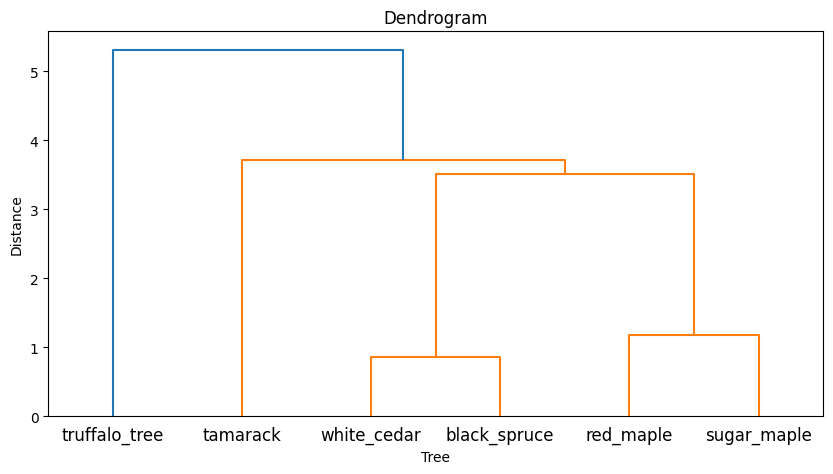

In [21]:
history = h_clustering(tree_dataframe_scaled, euclidean_distance)
print_hclustering(history, tree_dataframe_scaled, labels=list(tree_dataframe.index))

# Speak for the Trees!

Let's think about the results:


*   Which trees are similar? (Grouped)
*   How many tree groups (clusters) would you break these into?
*   How would you group or classify the new "Truffalo Tree" species?

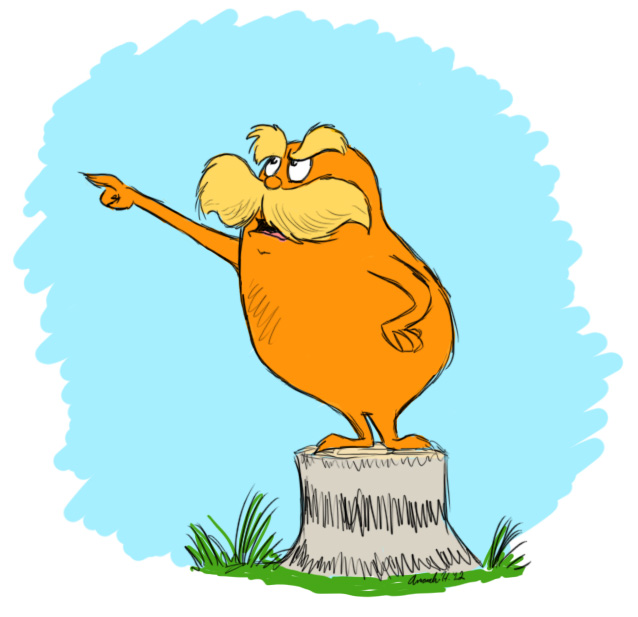



